In [1]:
from typing import Callable, Optional
import matplotlib.pyplot as plt
import numpy as np
import time
from tabulate import tabulate
import sys
from sklearn import linear_model
from scipy.stats import norm, bernoulli, multivariate_normal
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KernelDensity

#### SGLD applied to a Quadratic potential

We illustrate our algorithms with a quadratic example in which the solution of the continuous-time SGLD is explicit. We consider a fix value $\theta^* \in R^d$, $p_{\theta}$ the probability density of a Gaussian random variable with mean $\theta$ and covariance matrix $I_d$, and a constant $n\geq 1$. 

We observe $n$ *iid* random variables $X_1,X_2, \ldots, X_n$ with distribution $p_{\theta^*}$. We suppose that the prior distribution $\pi_0$ is a standard normal density function, then the posterior distribution is
$$
\mu_n(\theta ) \propto  \exp \left\{ - \frac{1}{n}\sum_{i=1}^n \frac{1+n}{2} \left\|\theta - \frac{n}{1+n} X_i \right\|_2^2 \right\}\propto \exp \left\{ - \frac{1+n}{2} \left\|\theta - \frac{n}{1+n} \overline{X}_n \right\|_2^2 \right\}, \quad \theta \in R^d.
$$
We then define  the continuous-time SGLD as the solution of the stochastic differential equation
$$
d \theta_t = (1+n) \left(\frac{n}{1+n} X_{V_j} -\theta_t\right) \, d t + \sqrt{2} \, d B_t,
$$
in the time interval $[S_{j-1}, S_j)$, for any $j\geq 1$, where:

- $\left(V_{j}\right)_{j \ge 1}$ is a sequence of *iid* random variables uniformly distributed in $[n]=\{1,2,\ldots,n\}$, 

- $\left(T_{j}\right)_{j \ge 1}$ is a sequence of *iid* random variables exponentially distributed with rate parameter $\alpha_n>0$,

- $S_0=0$ and $S_j = \displaystyle \sum_{k=1}^j T_{k}$, for $j\geq 1$,

- $\theta_0 \sim \mathcal{N}(0_d,\sigma^2_0 I_d)$ with $\sigma^2_0 = \frac{1}{2(n+1)}$. 

The exact solution at time $t\in (S_{j-1}, S_j)$ is
$$
\theta_t = \theta_{S_{j-1}} e^{-(1+n) (t-S_{j-1})} + \frac{n}{1+n} X_{V_j} (1-e^{-(1+n)(t-S_{j-1})}) + \sqrt{2} e^{-(1+n) t} \int_{S_{j-1}}^{t} e^{(1+n) s} \, d B(s).
$$
We take $t=S_j$ and deduce that 
$$
\left( \theta_{S_{j}} | \theta_{S_{j-1}},X_{V_j}, T_{j}, S_{j-1} \right) \sim \mathcal{N}(\mu_j, \sigma^2_jI_d)
$$
where
\begin{align}
\mu_j & = \theta_{S_{j-1}} e^{-(1+n)T_j} + \frac{n}{1+n} X_{V_j} (1-e^{-(1+n)T_j}), \\
\sigma^2_j &= \frac{1}{1+n} \left( 1 - e^{-2(1+n) T_{j} } \right).
\end{align}
for any $j \geq 1$. Similarly, we could deduce the distribution of $\left( \theta_t | \theta_{S_{j-1}}, X_{V_j}, T_{j}, S_{j-1} \right)$ for any $t\in (S_{j-1}, S_j)$, $j\geq 1$.

Theorem  shows that for any $\varepsilon>0$, if $\alpha_n = n$ and
$$
t \geq n^{-1} \left[ \log(\varepsilon^{-1}) + \log(d) + \log(n)  \right], 
$$
then the Kullback-Leibler divergence is smaller than $\varepsilon$.

Let us now illustrate the algorithm.

In [2]:
# normal distribution using mu_j and sigma^2_j

def Quadratic_sde_one_step(n: int, d: int, s0, s1, theta0, x1):
    # return theta_{S_i} using n, S_i, S_{i-1}, theta_{S_{i-1}} and X_i 
    
    mu = theta0 * np.exp((1+n)*(s0 - s1)) + x1 * (1.0 - np.exp((1+n)*(s0 - s1)) )/( 1 + 1/n )
    sigma = np.sqrt( (1.0 - np.exp(2*(1+n)*(s0 - s1)) )/(1+n) )
    
    return mu + sigma * np.random.multivariate_normal(np.zeros(d), np.eye(d))

In [3]:
class GridQuadraticSDE:
    # Simulate a path of SGLD 
    # return theta_{t_j}
    
    def __init__(self, d: int, x, alpha: float, t: float, m: int):
        self.d = d
        self.x = x.copy()
        self.n = len(self.x)
        self.alpha = alpha
        self.t = t
        self.m = m
    
    def run(self) -> np.ndarray:
        self._grid = np.linspace(0, self.t, self.m + 1) # grid
        
        # theta_0
        self._theta = np.random.multivariate_normal(np.zeros(self.d), np.eye(self.d)) / np.sqrt(2*(1.0+self.n))
        self._theta_history = [self._theta]
        self._theta_ave = [self._theta]
        
        self._S = [0.0]
        self._j = 1
        self._ti = 0
        
        while self._S[-1] < self.t:
            self._xi = self.x[np.random.choice(self.n)]    
            
            self._S.append(self._S[-1] + np.random.exponential(scale = 1/self.alpha)) # exponential interarrival times
            if self._S[-1] > T:
                self._S[-1] = T
            
            while self._grid[self._j] < self._S[-1]:
                # theta_t
                self._theta = Quadratic_sde_one_step(self.n, self.d, self._ti, self._grid[self._j], self._theta, self._xi)
                self._theta_history.append(self._theta)
                self._theta_ave.append( np.mean(self._theta_history, axis=0) )
                self._ti = self._grid[self._j]
                self._j += 1
            
            # theta_S
            self._theta = Quadratic_sde_one_step(self.n, self.d, self._ti, self._S[-1], self._theta, self._xi)   
            self._ti = self._S[-1]           
            if self._S[-1] == T:
                self._theta_history.append(self._theta)
                self._theta_ave.append( np.mean(self._theta_history, axis=0) )
                
    def trajectory(self) -> np.ndarray:
        return self._theta_history
    
    def cesaro_ave(self) -> np.ndarray:
        return self._theta_ave
    
    def nb_changes(self) -> int:
        return len(self._S)

### Simulation of a single path

We first generate a single path $(\theta_{S_{j}})_{j\geq 0}$ and verify that the squared error decreases as time increases. We consider 
- $n=1000$ *iid* observations,
- the real value $\theta^*=(1,1,\ldots,1) = 1_d$ of the parameter $\theta$,
- and $d= 3$. 

Theorem states that the optimal choice of $\alpha_n$ to obtain the convergence in entropy of the SGLD is $\alpha_n = n$. Although here we only observe the decay of the squared error of a path and not the entropy itself, let us compare different choices of $\alpha_n$. 

We simulate a path of the continuous-time SGLD for different values of $\alpha_n$ and we observe the decay of the squared error of the Césaro average for each path. A large value of $\alpha_n$ means that the process $(X_t)$ has a large number of jumps and therefore the error decreases rapidly, although as shown in the Table, the computational cost is higher. On the other hand, a small value of $\alpha_n$ means that the process $(X_t)$ has few jumps, the run-time is small, but the error is greater. As we expected, it seems that the value of $\alpha_n=n$ is the one that manages to balance the computational cost and a relatively small error, which is consistent with the result of Theorem.

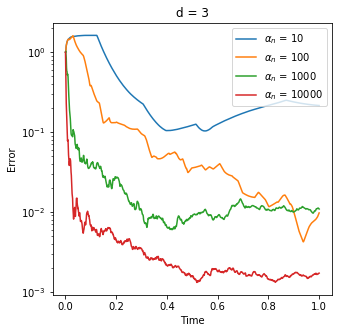

    α         MSE      Time    average number of changes of Xi
-----  ----------  --------  ---------------------------------
   10  0.213546    0.176123                                 10
  100  0.00968505  0.18538                                  94
 1000  0.0108439   0.258186                               1004
10000  0.00171014  0.93886                               10026


In [4]:
d = 3
theta_star = np.ones(d)

T = 1 # 
n = 1000 # number of Xi
m = 10**3 # number of intervals

x = np.random.multivariate_normal(theta_star, np.eye(d), size=n)

alpha = [10, 10**2, 10**3, 10**4]

t = np.linspace(0,T,m+1)
Cesaro_ave = np.zeros((m+1,d,len(alpha)))
error = np.zeros((m+1,len(alpha)))
nb_chg = np.zeros(len(alpha))

plt.figure(figsize=(5, 5))
head = ['\u03B1', 'MSE', 'Time', 'average number of changes of Xi']
mydata = []

for i, alpha_i in enumerate(alpha):
        
    start = time.time()
    
    np.random.seed(10)
    
    sde = GridQuadraticSDE(d, x, alpha_i, T, m)
    sde.run()
        
    Cesaro_ave[:,:,i] = np.array(sde.cesaro_ave()) 
    nb_chg[i] = sde.nb_changes()
        
    end = time.time()    

    for k in range(m+1):
        error[k,i] = mean_squared_error(theta_star, Cesaro_ave[k,:,i])
        
    label = f'{alpha_i}'
    plt.plot(t, error[:,i],label=r'$\alpha_n$ = '+label)
    
    # Table
    mydata += [ [alpha_i, error[-1,i], end-start, nb_chg[i] ] ] 
    
titlefig = 'd = '+ f'{d}'
plt.title(titlefig)
plt.yscale('log')
#plt.xscale('log')
plt.xlabel('Time')
plt.ylabel('Error')
plt.legend(loc=1)
plt.savefig('SGLD_quadratic_d100.pdf')
plt.show()
 
# display table
print(tabulate(mydata, headers=head, tablefmt="simple"))

#### Simulation of $M$ paths

We generate $M=100$ SGLD paths for different values of $n$ and $d$, to corroborate the influence of the number of observations on the order of convergence (of the mean squared error). Each of the paths was built with the corresponding $\alpha_n=n$ and we can observe that the MSE is lower as $n$ increases.

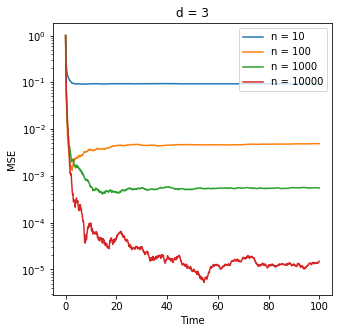

    α          MSE       Time    average number of changes of Xi
-----  -----------  ---------  ---------------------------------
10000  0.0924257      26.0412                     1001.97
10000  0.0048758      95.4565                     9997.82
10000  0.000548311   798.402                     99966.1
10000  1.49923e-05  7727.07                          1.00015e+06


In [7]:
d = 3
theta_star = np.ones(d)

T = 100
n = [10, 100, 1000, 10000] # number of Xi
m = 10**3 # number of intervals
M = 100 # number of trajectories

x1 = np.random.multivariate_normal(theta_star, np.eye(d), size=10000)
x2 = x1[:1000]
x3 = x1[:100]
x4 = x1[:10]

x = [x4, x3, x2, x1]

alpha = n

t = np.linspace(0,T,m+1)
Cesaro_ave = np.zeros((m+1,d,M,len(alpha)))
mean_Cesaro_ave = np.zeros((m+1,d,len(alpha)))
mse = np.zeros((m+1,len(alpha)))
nb_chg = np.zeros((M,len(alpha)))

plt.figure(figsize=(5, 5))
head = ['\u03B1', 'MSE', 'Time', 'average number of changes of Xi']
mydata = []

for i, ni in enumerate(n):
        
    start = time.time()
    
    np.random.seed(i)
    
    for j in range(M):
        sde = GridQuadraticSDE(d, x[i], alpha[i], T, m)
        sde.run()
        
        Cesaro_ave[:,:,j,i] = np.array(sde.cesaro_ave()) 
        nb_chg[j,i] = sde.nb_changes()
        
    end = time.time()    

    for k in range(m+1):
        mean_Cesaro_ave[k,:,i] = np.mean( Cesaro_ave[k,:,:,i], axis= 1)
        
        mse[k,i] = mean_squared_error(theta_star, mean_Cesaro_ave[k,:,i])
        
    label = f'{ni}'
    plt.plot(t, mse[:,i],label='n = '+label)
    
    # Table
    mydata += [ [alpha_i, mse[-1,i], end-start, np.mean(nb_chg[:,i]) ] ] 
    
titlefig = 'd = '+ f'{d}'
plt.title(titlefig)
plt.yscale('log')
#plt.xscale('log')
plt.xlabel('Time')
plt.ylabel('MSE')
plt.legend(loc=1)
plt.savefig('SGLD_quadratic_mse_d100.pdf')
plt.show()
 
# display table
print(tabulate(mydata, headers=head, tablefmt="simple"))